### Ejemplo de modelos regularizados en clasificación

In [12]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [13]:

# Cargar la base de datos breast cancer
data = load_breast_cancer()
X, y = data.data, data.target


In [14]:
# Crear un DataFrame con las características (X) y las etiquetas (y)
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [15]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [17]:

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:

# Establecer un escalador
scaler = StandardScaler()


In [19]:

# Definir los modelos de regresión logística con regularización Lasso, Ridge y Elastic Net
logreg_lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=10000)

logreg_ridge = LogisticRegression(penalty='l2', solver='saga', max_iter=10000)

logreg_elasticnet = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=10000)


In [20]:

# Configurar pipelines
pipe_lasso = Pipeline([('scaler', scaler),
                        ('logreg', logreg_lasso)])

pipe_ridge = Pipeline([('scaler', scaler),
                       ('logreg', logreg_ridge)])

pipe_elasticnet = Pipeline([('scaler', scaler),
                        ('logreg', logreg_elasticnet)])


In [21]:

# Definir los hiperparámetros para la búsqueda
param_grid_lasso = {'logreg__C': np.logspace(-4, 4, 10)}
param_grid_ridge = {'logreg__C': np.logspace(-4, 4, 10)}

param_grid_elasticnet = {'logreg__C': np.logspace(-4, 4, 10),
                         'logreg__l1_ratio': [0.1, 0.5, 0.9]}



### ¿Qué es Grid Search?

**Grid Search** es un método para buscar automáticamente los mejores hiperparámetros para un modelo de machine learning. Los **hiperparámetros** son configuraciones que se definen antes de entrenar el modelo (como el valor de regularización o la proporción de mezcla de regularizaciones). A diferencia de los **parámetros del modelo**, que se aprenden directamente de los datos (como los coeficientes en una regresión lineal), los hiperparámetros deben ajustarse manualmente.

El objetivo de Grid Search es encontrar la mejor combinación de estos hiperparámetros para mejorar el rendimiento del modelo en nuevas predicciones, es decir, su **capacidad de generalización**.

### ¿Cómo funciona Grid Search?

Grid Search explora todas las combinaciones posibles de los hiperparámetros que definamos en una cuadrícula de valores. Luego, por cada combinación, entrena el modelo y evalúa su rendimiento mediante validación cruzada.

### Paso a Paso de Grid Search

1. **Definir el modelo**: Empezamos con un modelo base. Por ejemplo, en una regresión logística, podríamos estar interesados en ajustar el parámetro de regularización (\(C\)).

2. **Crear una cuadrícula de hiperparámetros**: Decidimos qué valores queremos probar para cada hiperparámetro. Si queremos ajustar \(C\), podríamos probar valores como [0.01, 0.1, 1, 10, 100].

3. **Entrenar el modelo con cada combinación de hiperparámetros**: Grid Search entrena un modelo para cada combinación posible de los valores de hiperparámetros definidos en la cuadrícula.

4. **Validación Cruzada (Cross-Validation)**: Para cada combinación, Grid Search evalúa el rendimiento del modelo usando validación cruzada. Este proceso divide el conjunto de datos en varias partes (o "folds") y evalúa el modelo en diferentes particiones, asegurando que el rendimiento del modelo sea consistente.

5. **Seleccionar el mejor modelo**: Finalmente, Grid Search elige la combinación de hiperparámetros que da los mejores resultados según una métrica de rendimiento, como la precisión, la exactitud, etc.



In [22]:

# Realizar búsqueda en grilla con validación cruzada para cada modelo
grid_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, cv=5, scoring='accuracy')
grid_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=5, scoring='accuracy')
grid_elasticnet = GridSearchCV(pipe_elasticnet, param_grid_elasticnet, cv=5, scoring='accuracy')


In [23]:

# Ajustar los modelos
grid_lasso.fit(X_train, y_train)
grid_ridge.fit(X_train, y_train)
grid_elasticnet.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logreg',
                                        LogisticRegression(max_iter=10000,
                                                           penalty='elasticnet',
                                                           solver='saga'))]),
             param_grid={'logreg__C': array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]),
                         'logreg__l1_ratio': [0.1, 0.5, 0.9]},
             scoring='accuracy')

Hagamos un pequeño zoom a los resultados que se obtuvieron por ejemplo para lasso

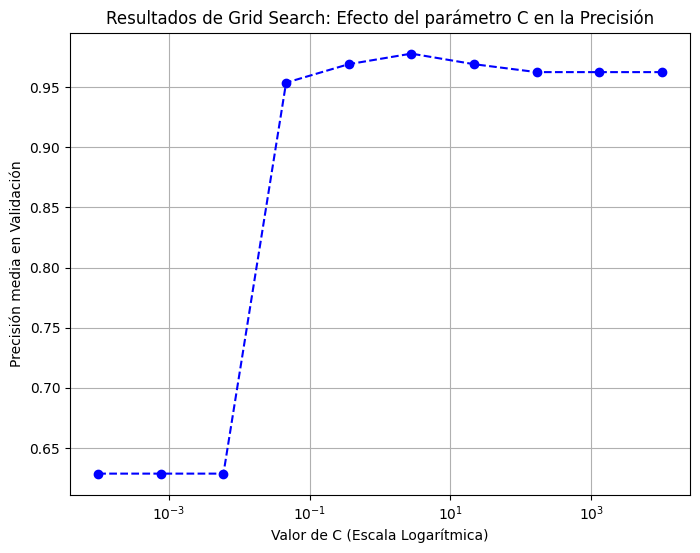

In [24]:
import matplotlib.pyplot as plt

# Obtener los resultados del Grid Search
results = grid_lasso.cv_results_

# Extraer los valores de C y sus respectivas medias de precisión
Cs = param_grid_lasso['logreg__C']
mean_test_scores = results['mean_test_score']

# Graficar el rendimiento del modelo para diferentes valores de C
plt.figure(figsize=(8, 6))
plt.plot(Cs, mean_test_scores, marker='o', linestyle='--', color='b')
plt.xscale('log')  # Escala logarítmica para mejor visualización
plt.title('Resultados de Grid Search: Efecto del parámetro C en la Precisión')
plt.xlabel('Valor de C (Escala Logarítmica)')
plt.ylabel('Precisión media en Validación')
plt.grid(True)
plt.show()

In [25]:

# Obtener los mejores resultados de cada modelo
best_lasso = grid_lasso.best_score_
best_ridge = grid_ridge.best_score_
best_elasticnet = grid_elasticnet.best_score_



In [26]:
# Mostrar resultados
results = pd.DataFrame({
    'Model': ['Lasso', 'Ridge', 'ElasticNet'],
    'Best Score': [best_lasso, best_ridge, best_elasticnet],
    'Best Params': [grid_lasso.best_params_, grid_ridge.best_params_, grid_elasticnet.best_params_]
})
results

,Model,Best Score,Best Params
0,Lasso,0.978022,{'logreg__C': 2.782559402207126}
1,Ridge,0.975824,{'logreg__C': 2.782559402207126}
2,ElasticNet,0.978022,"{'logreg__C': 2.782559402207126, 'logreg__l1_r..."


In [27]:
grid_elasticnet.best_params_

{'logreg__C': 2.782559402207126, 'logreg__l1_ratio': 0.1}

Cuando entrenamos un modelo utilizando **Grid Search** con `scikit-learn`, podemos extraer una gran cantidad de información útil después del ajuste. A continuación, se describen las principales funciones y atributos que los estudiantes pueden utilizar para obtener los resultados más relevantes de su Grid Search, y qué tipo de análisis pueden hacer con esa información.

### 1. `best_params_`: Los Mejores Hiperparámetros
Este es probablemente el atributo más importante y utilizado después de entrenar un modelo con Grid Search. Al ejecutar `grid_search.best_params_`, se obtienen los hiperparámetros que dieron los mejores resultados durante la validación cruzada.

**Ejemplo**:
```python
print("Mejores hiperparámetros:", grid_search.best_params_)
```
Esto es especialmente útil para ver cuál fue la combinación de hiperparámetros que maximizó el rendimiento del modelo. Si se está ajustando un parámetro como \(C\) en la regresión logística, `best_params_` te dirá cuál es el mejor valor de \(C\).

### 2. `best_score_`: El Mejor Resultado de Validación
El atributo `best_score_` devuelve la puntuación más alta obtenida durante la validación cruzada, utilizando la métrica de evaluación definida (por defecto, precisión).

**Ejemplo**:
```python
print("Mejor puntuación de validación:", grid_search.best_score_)
```
Esto permite saber cuán bien funcionó el modelo con la mejor combinación de hiperparámetros y qué tan cerca estamos del rendimiento óptimo.

### 3. `best_estimator_`: El Mejor Modelo Entrenado
Con `grid_search.best_estimator_`, podemos acceder directamente al modelo entrenado con los mejores hiperparámetros. Este modelo ya está listo para hacer predicciones sobre nuevos datos.

**Ejemplo**:
```python
best_model = grid_search.best_estimator_
```
Es útil si queremos tomar este modelo final y aplicarlo directamente a datos de prueba o realizar otras evaluaciones adicionales.

### 4. `cv_results_`: Resultados Detallados del Grid Search
El atributo `cv_results_` es una mina de oro de información. Es un diccionario que contiene información detallada sobre cada combinación de hiperparámetros probada, como las puntuaciones de validación y el tiempo de ejecución.

**Ejemplo**:
```python
print(grid_search.cv_results_.keys())  # Para ver todas las claves disponibles
```

Algunas claves interesantes en `cv_results_` incluyen:
- **`mean_test_score`**: Las puntuaciones medias obtenidas en la validación cruzada para cada combinación de hiperparámetros.
- **`std_test_score`**: La desviación estándar de las puntuaciones de validación, lo que ayuda a entender la variabilidad en el rendimiento.
- **`params`**: Las combinaciones de hiperparámetros que se probaron.

**Ejemplo de uso**:
```python
mean_scores = grid_search.cv_results_['mean_test_score']
params = grid_search.cv_results_['params']
for mean, param in zip(mean_scores, params):
    print(f"Score: {mean}, Params: {param}")
```
Esto es muy útil para entender cómo diferentes combinaciones de hiperparámetros afectaron el rendimiento del modelo.

### 5. `refit`: Reentrenar el Mejor Modelo
Si `refit=True` (que es el valor por defecto en `GridSearchCV`), el modelo se reentrena automáticamente utilizando los mejores hiperparámetros en todo el conjunto de datos de entrenamiento después de completar la búsqueda.

**Ejemplo**:
```python
grid_search.refit
```
Esto garantiza que el modelo final se entrene con la combinación óptima de hiperparámetros, y luego se puede utilizar para predecir o evaluar con datos nuevos.

### 6. `scorer_`: La Función de Scoring
El atributo `scorer_` muestra la métrica que se utilizó para evaluar los modelos durante la validación cruzada. Esto es útil para verificar qué función se usó cuando se especificó el parámetro `scoring`.

**Ejemplo**:
```python
print("Función de scoring utilizada:", grid_search.scorer_)
```

### 7. `n_splits_`: Número de Divisiones en la Validación Cruzada
Este atributo indica cuántas divisiones (folds) se utilizaron en la validación cruzada. Esto es útil para tener en cuenta cuántas veces se entrenó y evaluó el modelo.

**Ejemplo**:
```python
print("Número de divisiones en la validación cruzada:", grid_search.n_splits_)
```




In [28]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
# Evaluamos el mejor modelo en el conjunto de prueba

best_model = grid_lasso.best_estimator_  # Seleccionamos el mejor modelo (en este caso Lasso)

# Hacemos predicciones en el conjunto de prueba
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calculamos las métricas mencionadas
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)
classification_rep = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Función para mostrar métricas de manera más estética
def show_metrics(accuracy, f1, auc_roc, classification_rep, conf_matrix):
    # Mostrar las métricas generales
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {auc_roc:.4f}\n")

    # Mostrar el classification report
    print("Classification Report:\n")
    print(classification_rep)

    # Mostrar la matriz de confusión usando seaborn para hacerlo más visual
    plt.figure(figsize=(6,4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Clase 0", "Clase 1"], yticklabels=["Clase 0", "Clase 1"])
    plt.title("Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


Accuracy: 0.9737
F1 Score: 0.9787
AUC-ROC: 0.9961

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



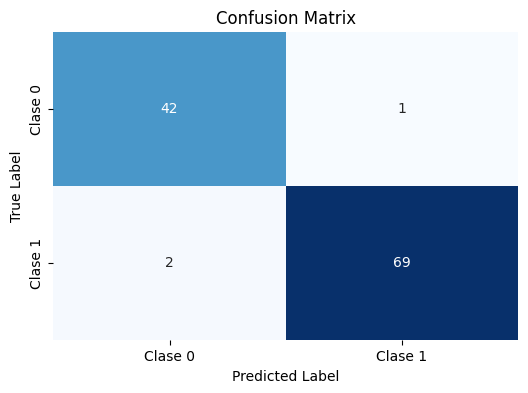

In [29]:

# Llamamos a la función para mostrar las métricas de manera más bonita
show_metrics(accuracy, f1, auc_roc, classification_rep, conf_matrix)



1. **Clases 0 y 1**:
   - La clase "0" corresponde a los casos donde el modelo predice que un tumor es **benigno**.
   - La clase "1" corresponde a los casos donde el modelo predice que un tumor es **maligno**.

2. **Precisión (Precision)**:
   - Para la clase "0" (benigno), la precisión es de **0.95**, lo que significa que el 95% de las predicciones de tumores benignos son correctas.
   - Para la clase "1" (maligno), la precisión es de **0.99**, lo que indica que el 99% de las predicciones de tumores malignos son correctas.

3. **Recall (Sensibilidad o Tasa de Verdaderos Positivos)**:
   - Para la clase "0", el recall es de **0.98**, lo que significa que el 98% de los tumores benignos reales fueron identificados correctamente.
   - Para la clase "1", el recall es de **0.97**, lo que indica que el 97% de los tumores malignos reales fueron correctamente identificados como malignos.

4. **F1-Score**:
   - Para la clase "0", el F1-score es de **0.97**, lo que es una combinación del balance entre precisión y recall.
   - Para la clase "1", el F1-score es de **0.98**, lo que refleja un excelente rendimiento en la predicción de tumores malignos.

5. **Support**:
   - El soporte ("support") muestra cuántos casos de cada clase había en el conjunto de prueba. En este caso, había **43** tumores benignos (clase 0) y **71** tumores malignos (clase 1).

### Interpretación:
El modelo tiene un excelente rendimiento en la clasificación de tumores benignos y malignos en el conjunto de datos del cáncer de mama. El alto valor de precisión para la clase "1" (99%) es especialmente importante, ya que significa que casi todos los tumores malignos predichos son realmente malignos. Del mismo modo, el alto recall para ambas clases muestra que el modelo es muy capaz de identificar correctamente tanto los tumores benignos como malignos.


In [34]:
# Extraer el modelo de regresión logística del pipeline
logreg_model = best_model.named_steps['logreg']  # Cambia 'logreg' por el nombre del paso que le diste en tu pipeline

# Obtener los coeficientes del modelo
coef = logreg_model.coef_[0]  # Los coeficientes están en un array 2D, seleccionamos el primero

# Obtener los nombres de las características del conjunto de datos
feature_names = data.feature_names

# Crear un DataFrame para ordenar los coeficientes
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef})

# Ordenar los coeficientes en orden descendente de valor absoluto
coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)

print(coef_df)  # Ver los coeficientes ordenados

                    Feature  Coefficient
7       mean concave points    -3.793726
10             radius error    -3.304167
21            worst texture    -2.265956
28           worst symmetry    -2.032640
26          worst concavity    -2.015343
20             worst radius    -1.607824
23               worst area    -1.537415
13               area error    -1.124010
5          mean compactness     1.052867
18           symmetry error     0.993699
15        compactness error     0.933692
14         smoothness error    -0.774978
19  fractal dimension error     0.525959
8             mean symmetry     0.518530
27     worst concave points    -0.503822
11            texture error     0.474471
16          concavity error     0.282434
6            mean concavity    -0.068986
25        worst compactness     0.000000
24         worst smoothness     0.000000
22          worst perimeter     0.000000
0               mean radius     0.000000
17     concave points error     0.000000
1              m